# Spaceship Titanic — End-to-End Supervised Learning Pipeline

**Goal:** Predict whether each passenger was `Transported` to an alternate dimension, using a clean, leakage-safe, reusable supervised learning workflow built entirely with `scikit-learn`.

This notebook is written to double as a **template for future supervised learning (classification) projects**. Every section follows a fixed, professional structure:

| # | Section | What it does |
|---|---------|---------------|
| 1 | Setup & Imports | All libraries in one place |
| 2 | Load Data | Read raw train/test CSVs |
| 3 | Exploratory Data Analysis | Understand the data before touching it |
| 4 | Feature Engineering | Deterministic, leakage-free transformations |
| 5 | Train/Validation Split | Split **before** fitting any preprocessing |
| 6 | Preprocessing Pipeline | `ColumnTransformer` — imputing, scaling, encoding |
| 7 | Baseline Model | Simple model to beat |
| 8 | Model Comparison | Cross-validated comparison of several algorithms |
| 9 | Hyperparameter Tuning | `GridSearchCV` on the strongest candidate |
| 10 | Final Evaluation | Metrics on a held-out validation set |
| 11 | Feature Importance | Which features actually drive predictions |
| 12 | Refit on Full Data | Train the final model on 100% of labeled data |
| 13 | Kaggle Submission | Predict on `test.csv` and write `submission.csv` |
| 14 | Reusable Checklist | The good-practice rules to carry into your next project |

> **Core principle used throughout:** any step that *learns from data* (imputing medians, scaling, encoding, fitting a model) is wrapped in a `scikit-learn` `Pipeline`/`ColumnTransformer` and fit **only on the training fold**. Steps that don't learn anything (splitting a string column, summing existing columns) are safe to do before the split. This is the single most common source of inflated, unrealistic accuracy in beginner projects — avoiding it is the main "professional" habit this notebook is built around.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline


## 2. Load Data

Update `DATA_DIR` if your folder layout differs. This notebook assumes the standard Kaggle Spaceship Titanic layout: `train.csv` (labeled) and `test.csv` (unlabeled, used for the final submission).

In [2]:
DATA_DIR = Path("../data")

train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")

print("train shape:", train_raw.shape)
print("test shape :", test_raw.shape)
train_raw.head()


train shape: (8693, 14)
test shape : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. Exploratory Data Analysis (EDA)

**Good practice:** EDA is read-only. Nothing here should change the data — it's purely to build understanding before you make preprocessing decisions.

In [3]:
train_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [4]:
train_raw.describe()


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
train_raw.isna().mean().sort_values(ascending=False) * 100  # % missing per column


CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
PassengerId     0.000000
Transported     0.000000
dtype: float64

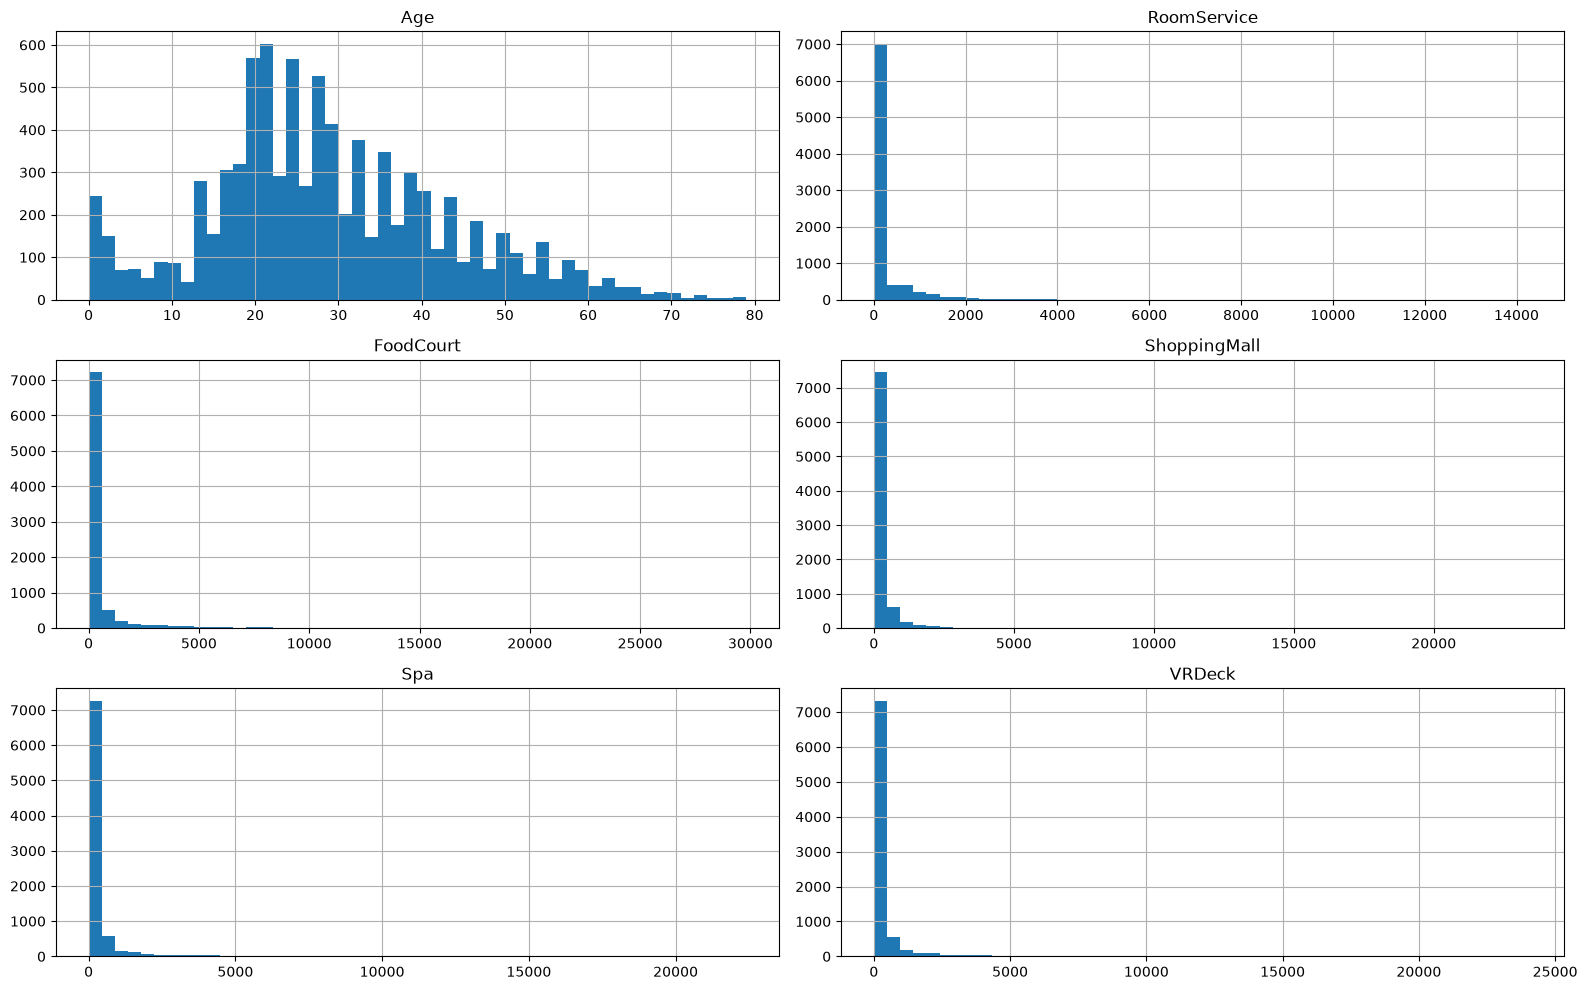

In [6]:
train_raw.hist(bins=50, figsize=(16, 10))
plt.tight_layout()
plt.show()


In [7]:
print("Target balance:")
print(train_raw["Transported"].value_counts(normalize=True))


Target balance:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


**Takeaways carried into modeling** (from the correlation and mutual-information analysis done earlier in exploration):
- `CryoSleep` is the single strongest predictor (linear and non-linear).
- Spending columns (`RoomService`, `Spa`, `VRDeck`, `ShoppingMall`, `FoodCourt`) matter much more than their raw Pearson correlation suggested — mutual information revealed a non-linear relationship, largely because cryosleep passengers spend nothing.
- `HomePlanet`, `Deck`, `Side` carry moderate signal.
- The target classes are roughly balanced (~50/50), so plain accuracy is a reasonable primary metric (no need for class-weighting or resampling).

## 4. Feature Engineering

**Good practice:** wrap feature engineering in a function so the *exact same* transformations are applied to `train`, the validation split, and the real Kaggle `test.csv`. Never repeat this logic by hand in multiple places — that's a common source of train/test mismatches.

Everything here is **deterministic** (string splitting, arithmetic, grouping within a single dataframe) — it doesn't "learn" any statistic from the data, so it's safe to apply before the train/validation split.

In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered columns. Safe to call on train, validation, or test data independently."""
    df = df.copy()

    # Cabin -> Deck / CabinNum / Side
    df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)
    df["CabinNum"] = pd.to_numeric(df["CabinNum"], errors="coerce")

    # Total amount spent across all onboard services
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["TotalSpend"] = df[spend_cols].sum(axis=1)

    # Group membership from PassengerId (format: "gggg_pp")
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df.groupby("Group")["Group"].transform("count")

    # CryoSleep / VIP as clean 0/1 (still may contain NaN -> imputed later in the pipeline)
    df["CryoSleep"] = df["CryoSleep"].map({True: 1, False: 0})
    df["VIP"] = df["VIP"].map({True: 1, False: 0})

    return df


train_fe = engineer_features(train_raw)
test_fe = engineer_features(test_raw)

train_fe.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side,TotalSpend,Group,GroupSize
0,0001_01,Europa,0.0,B/0/P,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P,0.0,0001,1
1,0002_01,Earth,0.0,F/0/S,TRAPPIST-1e,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S,736.0,0002,1
2,0003_01,Europa,0.0,A/0/S,TRAPPIST-1e,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S,10383.0,0003,2
3,0003_02,Europa,0.0,A/0/S,TRAPPIST-1e,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S,5176.0,0003,2
4,0004_01,Earth,0.0,F/1/S,TRAPPIST-1e,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S,1091.0,0004,1


## 5. Train / Validation Split

**Good practice — do this before fitting anything.** The validation set exists to estimate how the model performs on unseen data. If any preprocessing step (imputer medians, scaler mean/std, encoder categories) is fit before this split, information from the validation set leaks into training, and your validation score becomes an overly optimistic lie.

`stratify=y` keeps the ~50/50 class balance identical in both splits.

In [9]:
TARGET = "Transported"

feature_cols = [
    "HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
    "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
    "Deck", "CabinNum", "Side", "TotalSpend", "GroupSize",
]

X = train_fe[feature_cols]
y = train_fe[TARGET].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train:", X_train.shape, " X_val:", X_val.shape)


X_train: (6954, 15)  X_val: (1739, 15)


## 6. Preprocessing Pipeline

**Good practice:** use `ColumnTransformer` + `Pipeline` instead of manually calling `fit_transform` on the whole dataset. This gives you three things for free:

1. **No leakage** — `.fit()` is called only on `X_train`; `X_val`/`X_test` only ever see `.transform()`.
2. **No repeated code** — the exact same preprocessing logic is reused for validation, refitting, and the Kaggle test set.
3. **Portability** — the whole pipeline (preprocessing *and* model) can be saved/loaded as a single object.

Three groups of columns, each handled differently:
- **Numeric** (`Age`, spend columns, `TotalSpend`, `GroupSize`, `CabinNum`): median imputation, then standard scaling.
- **Categorical** (`HomePlanet`, `Destination`, `Deck`, `Side`): most-frequent imputation, then one-hot encoding.
- **Binary/boolean** (`CryoSleep`, `VIP`): most-frequent imputation only (already 0/1).

In [10]:
numeric_features = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
                    "TotalSpend", "GroupSize", "CabinNum"]
categorical_features = ["HomePlanet", "Destination", "Deck", "Side"]
binary_features = ["CryoSleep", "VIP"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
    ("bin", binary_pipeline, binary_features),
])


## 7. Baseline Model

**Good practice:** always establish a simple baseline before reaching for complex models. If a Random Forest can't clearly beat logistic regression, the extra complexity isn't earning its keep.

In [11]:
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

baseline_pipeline.fit(X_train, y_train)
baseline_preds = baseline_pipeline.predict(X_val)

print(f"Baseline (Logistic Regression) validation accuracy: {accuracy_score(y_val, baseline_preds):.4f}")


Baseline (Logistic Regression) validation accuracy: 0.7884


## 8. Model Comparison (Cross-Validation)

**Good practice:** compare several model families using cross-validation on the *training* set only (`X_val`/`y_val` stay untouched until final evaluation). This gives a more stable estimate than a single split and helps pick which model is worth tuning.

In [12]:
candidate_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVC": SVC(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, clf in candidate_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = scores
    print(f"{name:22s} mean accuracy = {scores.mean():.4f}  (+/- {scores.std():.4f})")


LogisticRegression     mean accuracy = 0.7902  (+/- 0.0048)
RandomForest           mean accuracy = 0.8003  (+/- 0.0052)
HistGradientBoosting   mean accuracy = 0.8103  (+/- 0.0021)
SVC                    mean accuracy = 0.8023  (+/- 0.0042)


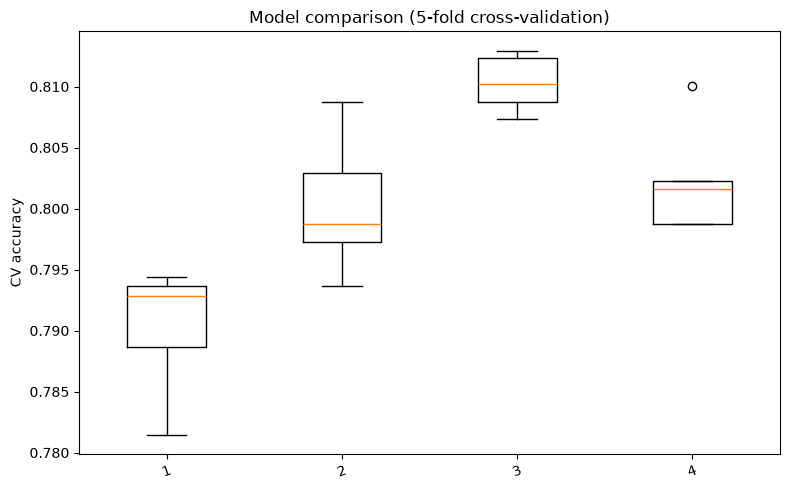

In [14]:
plt.figure(figsize=(8, 5))
plt.boxplot(results.values(), label=results.keys())
plt.ylabel("CV accuracy")
plt.title("Model comparison (5-fold cross-validation)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**How to read this:** pick the model with the best *median* CV score and an acceptably tight spread (a model that's occasionally great and occasionally poor across folds is a riskier bet than one that's consistently good). For this dataset, tree-based / boosting methods typically edge out plain logistic regression because of the non-linear interactions found earlier (e.g. `CryoSleep` × spending). Whichever model wins on your run, carry its name into the next section.

## 9. Hyperparameter Tuning

**Good practice:** tune only the model that won the comparison above — don't grid-search every candidate, it wastes compute. Below tunes `RandomForestClassifier` as an example; swap in the winning model's parameter grid if a different one performed best for you.

`GridSearchCV` re-runs cross-validation internally, so this is still leakage-safe — the grid search only ever sees `X_train`/`y_train`.

In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier

param_grid = {
    "classifier__max_iter": [100, 200, 300],
    "classifier__max_depth": [None, 6, 10],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__l2_regularization": [0.0, 0.1, 1.0],
}

tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best CV accuracy:", grid_search.best_score_)
print("Best params:", grid_search.best_params_)

best_pipeline = grid_search.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best CV accuracy: 0.8111880588986754
Best params: {'classifier__l2_regularization': 0.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': None, 'classifier__max_iter': 100}


## 10. Final Evaluation on Validation Set

**Good practice:** this is the *one time* the validation set gets used for scoring — after tuning is finished. Never tune hyperparameters against the validation set itself, or it stops being an honest estimate of unseen performance (it becomes a second training set in disguise).

In [16]:
val_preds = best_pipeline.predict(X_val)

print(f"Final validation accuracy: {accuracy_score(y_val, val_preds):.4f}\n")
print(classification_report(y_val, val_preds, target_names=["Not Transported", "Transported"]))


Final validation accuracy: 0.8143

                 precision    recall  f1-score   support

Not Transported       0.82      0.80      0.81       863
    Transported       0.81      0.83      0.82       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



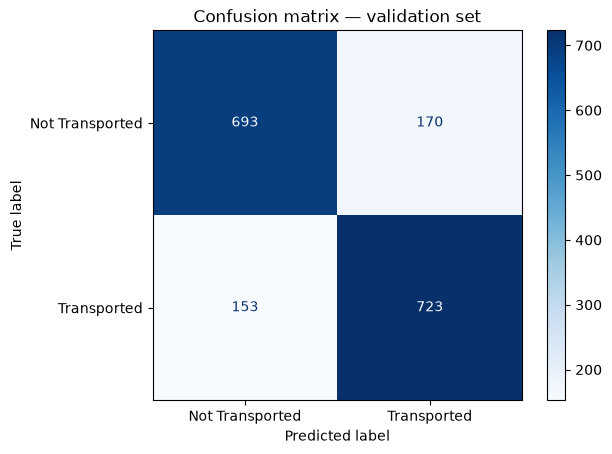

In [17]:
cm = confusion_matrix(y_val, val_preds)
ConfusionMatrixDisplay(cm, display_labels=["Not Transported", "Transported"]).plot(cmap="Blues")
plt.title("Confusion matrix — validation set")
plt.show()


## 11. Feature Importance

Which features is the tuned model actually relying on? Useful both to sanity-check the model (does it match domain intuition from the EDA?) and to simplify future iterations.

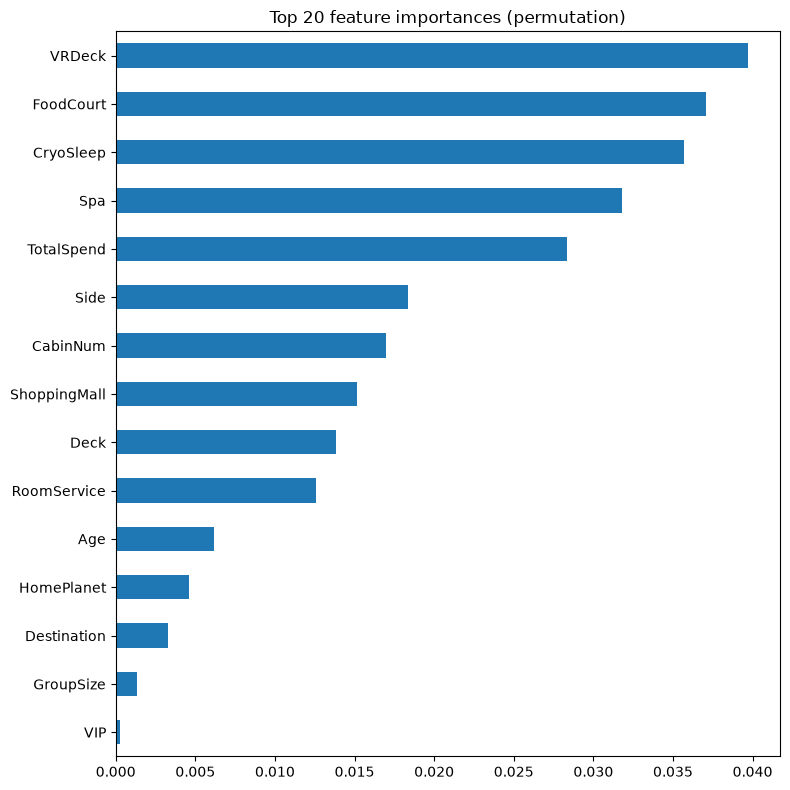

VRDeck          0.039735
FoodCourt       0.037090
CryoSleep       0.035710
Spa             0.031800
TotalSpend      0.028350
Side            0.018344
CabinNum        0.016964
ShoppingMall    0.015124
Deck            0.013859
RoomService     0.012593
Age             0.006153
HomePlanet      0.004600
Destination     0.003278
GroupSize       0.001323
VIP             0.000288
dtype: float64

In [19]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_pipeline, X_val, y_val,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

importance_series = pd.Series(
    perm_result.importances_mean,
    index=X_val.columns  # raw column names, not one-hot expanded names
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importance_series.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 feature importances (permutation)")
plt.tight_layout()
plt.show()

importance_series.head(15)

## 12. Refit on Full Training Data

**Good practice:** once you're satisfied with the tuned model's validation performance, refit it on **all** labeled data (`X_train` + `X_val` combined) before generating the real submission. The validation split was only ever a tool to estimate performance and choose hyperparameters — throwing away 20% of your labeled data at submission time leaves accuracy on the table.

Use the *same* hyperparameters found by `grid_search`, but fit fresh preprocessing + model on the full set.

In [20]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        **{k.replace("classifier__", ""): v for k, v in grid_search.best_params_.items()}
    )),
])

final_pipeline.fit(X, y)  # X, y = full engineered training set, before the validation split
print("Refit complete on full training data:", X.shape[0], "rows")


Refit complete on full training data: 8693 rows


## 13. Predict on Test Set & Create Kaggle Submission

`test.csv` has no `Transported` column — that's what you're predicting. Apply the exact same `engineer_features` function used earlier, then let the fitted pipeline (which already knows how to impute/scale/encode) handle the rest.

In [21]:
X_test = test_fe[feature_cols]

test_preds = final_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Transported": test_preds.astype(bool),
})

submission.to_csv("submission.csv", index=False)
submission.head()


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


`submission.csv` is now saved in the current working directory and ready to upload to Kaggle.

## 14. Reusable Checklist — Good Practices for Future Supervised Learning Projects

Keep this section as a mental checklist for the next classification/regression project:

1. **EDA before anything else.** Understand missingness, distributions, class balance, and rough feature-target relationships before writing preprocessing code.
2. **Check correlation *and* mutual information / feature importance.** Linear correlation misses real signal — several features here (`RoomService`, `ShoppingMall`) looked weak under Pearson correlation but were strong under mutual information.
3. **Engineer deterministic features before splitting; fit statistical steps only after splitting.** Splitting a string, summing existing columns = safe before split. Imputing a median, scaling, fitting an encoder's categories = must happen after split, on train only.
4. **Always hold out a validation set**, even when a separate unlabeled Kaggle test set exists — you need a way to score yourself locally before spending a submission.
5. **Use `Pipeline` + `ColumnTransformer`**, not manual `fit_transform` calls, so preprocessing can never leak and is guaranteed identical across train/val/test.
6. **Establish a simple baseline model first** (e.g. logistic regression) before reaching for ensembles — know what you're actually gaining from complexity.
7. **Compare multiple model families with cross-validation**, not a single train/val split, before deciding what to tune.
8. **Tune only the winning model.** Use `GridSearchCV`/`RandomizedSearchCV`, scored via cross-validation on the training set only.
9. **Touch the validation set for scoring exactly once**, after tuning is finished — never tune against it.
10. **Refit the final tuned pipeline on 100% of labeled data** before generating real predictions/submissions.
11. **Inspect feature importances** at the end — a sanity check that the model's reasoning matches domain intuition, and a guide for what to simplify or engineer further next time.